

**Name:** Joseph Wong 
Urban Data Science & Smart Cities <br>
URSP688Y Spring 2026<br>
Instructor: Chester Harvey <br>
Urban Studies & Planning <br>
National Center for Smart Growth <br>
University of Maryland


# Exercise 3: Transit Access and Eviction Outcomes in Maryland's DC Suburbs

## Abstract

This analysis investigates whether proximity to Washington Metropolitan Area Transit Authority (WMATA) Metro stations is associated with higher eviction warrant filing rates and worse eviction outcomes in Prince George's and Montgomery Counties, Maryland. Transit-accessible neighborhoods are often subject to displacement pressures from transit-oriented development and rising rents, yet they may also house lower-income renters with fewer resources to contest eviction proceedings. Using address-level eviction warrant data spanning 2020–2024 merged with WMATA Metro station locations obtained from a regional GeoJSON file, we construct ZIP-code-level measures of eviction activity and calculate the geodesic distance from each ZIP code's centroid to its nearest Metro station. We then categorize ZIP codes into four proximity zones (under 1 mile, 1–3 miles, 3–6 miles, and over 6 miles) and compare both the raw volume of eviction warrant filings and the *eviction execution rate* — the share of returned warrants resulting in an actual eviction rather than cancellation — across these zones.

Our findings reveal that ZIP codes within 1 mile of a Metro station concentrate a disproportionate share of eviction warrant filings relative to their share of ZIP codes, particularly in Prince George's County. However, the eviction execution rate (executed evictions as a share of returned warrants) is not uniformly higher near transit: mid-distance ZIP codes (1–3 miles) show the highest execution rates, suggesting that the very-near-transit neighborhoods may contain more tenant advocacy resources or organized renters, while the peri-urban fringe — far from both transit and urban services — faces the highest risk of an eviction proceeding culminating in actual removal. These patterns highlight the spatial inequity in eviction risk across Maryland's inner suburbs and point to transit proximity as a meaningful, but non-linear, predictor of housing instability.


---
## 0. Setup and Imports

In [ ]:
# Install dependencies (run once)
%pip install geopandas shapely zipcodes matplotlib seaborn

In [2]:
import sys
!{sys.executable} -m pip install pandas geopandas matplotlib seaborn shapely zipcodes numpy

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached zipcodes-1.3.0-py2.py3-none-any.whl.metadata (7.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached zipcodes-1.3.0-py2.py3-none-any.whl (726 kB)

   -------------------- ------------------- 1/2 [seaborn]
   -------------------- ------------------- 1/2 [seaborn]
   -------------------- ------------------- 1/2 [seaborn]
   -------------------- ------------------- 1/2 [seaborn]
   ---------------------------------------- 2/2 [seaborn]



In [3]:
import json
import math
import warnings
warnings.filterwarnings('ignore')


import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from shapely.geometry import Point

# For ZIP code centroid lookup (static package, no network needed)
import zipcodes

print("All imports successful.")

All imports successful.


In [4]:
import sys
print("Python path:", sys.executable)
print("Python version:", sys.version)

import subprocess
result = subprocess.run([sys.executable, "-m", "pip", "list"], capture_output=True, text=True)
print(result.stdout)

Python path: h:\urbandatascience\python.exe
Python version: 3.13.11 | packaged by Anaconda, Inc. | (main, Dec 10 2025, 21:21:58) [MSC v.1929 64 bit (AMD64)]
Package                  Version
------------------------ -----------
anaconda-anon-usage      0.7.5
anaconda-auth            0.12.3
anaconda-cli-base        0.7.0
annotated-types          0.6.0
archspec                 0.2.5
asttokens                3.0.1
boltons                  25.0.0
branca                   0.8.2
brotlicffi               1.2.0.0
certifi                  2026.2.25
cffi                     2.0.0
charset-normalizer       3.4.4
click                    8.2.1
colorama                 0.4.6
comm                     0.2.3
conda                    26.1.1
conda-anaconda-telemetry 0.3.0
conda-anaconda-tos       0.2.2
conda-content-trust      0.2.0
conda-libmamba-solver    25.11.0
conda-package-handling   2.4.0
conda_package_streaming  0.12.0
contourpy                1.3.3
cryptography             46.0.3
cycler          

---
## 1. Load and Clean Eviction Warrant Data

We focus on Prince George's County and Montgomery County — the two Maryland counties in the WMATA service area — and restrict to complete calendar years 2020–2024.

In [ ]:
# ----- Load raw data -----
df_raw = pd.read_csv('md_eviction_warrants_through_sept2025.csv')
print(f"Raw dataset: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
df_raw.head(3)



Raw dataset: 607,881 rows × 18 columns


,Unnamed: 0,ID,EventDate,EventType,EventComment,County,Location,TenantAddress,TenantCity,TenantState,TenantZipCode,CaseType,CaseNumber,EvictedDate,Source,SourceDate,Year,EvictionYear
0,0,NaN,2025-09-30,WarrantofRestitution-ReturnofService-Cancelled,NaN,Baltimore,Essex,8-NGLENSHANONCOURT,Baltimore,MD,21221.0,FailuretoPayRent,D-08-LT-25-65546-028,NaN,09/2025-WarrantofRestitution-ReturnofService-C...,10/24/2025,2025.0,NaN
1,1,NaN,2025-09-30,WarrantofRestitution-ReturnofService-Evicted,NaN,PrinceGeorge's,Hyattsville,1009KENNEBECSTREET1F,OXONHILL,MD,20745.0,FailuretoPayRent,D-05-LT-25-57928-001,9/18/2025,09/2025-WarrantofRestitution-ReturnofService-E...,10/24/2025,2025.0,2025.0
2,2,NaN,2025-09-30,WarrantofRestitution-ReturnofService-Cancelled,NaN,Baltimore,Essex,1407-MCLEARSTREAMRD,Baltimore,MD,21221.0,FailuretoPayRent,D-08-LT-25-65581-027,NaN,09/2025-WarrantofRestitution-ReturnofService-C...,10/24/2025,2025.0,NaN


In [6]:
# ----- Filter to PG + Montgomery counties, complete years, valid ZIP -----
TARGET_COUNTIES = ["PrinceGeorge's", "Montgomery"]

df = df_raw[
    df_raw['County'].isin(TARGET_COUNTIES)
].copy()

# Clean ZIP codes: coerce to numeric, keep only plausible MD suburbs range
df['ZipCode'] = pd.to_numeric(df['TenantZipCode'], errors='coerce')
df = df[(df['ZipCode'] >= 20600) & (df['ZipCode'] <= 21000)].copy()
df['ZipCode'] = df['ZipCode'].astype(int).astype(str).str.zfill(5)

# Filter to complete calendar years 2020–2024
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df = df[df['Year'].isin([2020, 2021, 2022, 2023, 2024])]

# Standardise EventType labels
df['EventType'] = df['EventType'].str.strip()

print(f"Filtered dataset: {len(df):,} rows")
print(f"\nEvent type breakdown:")
print(df['EventType'].value_counts())

Filtered dataset: 95,970 rows

Event type breakdown:
EventType
Petition-ForWarrantofRestitutionFiled             61724
WarrantofRestitution-ReturnofService-Cancelled    22805
WarrantofRestitution-ReturnofService-Evicted       8129
WarrantofRestitution-ReturnofService-Expired       3269
petition-ForWarrantofRestitutionFiled                43
Name: count, dtype: int64


In [7]:
# ----- Classify each record into a clean outcome category -----
def classify_event(et):
    et = str(et)
    if 'Evicted' in et:
        return 'Executed'
    elif 'Cancelled' in et:
        return 'Cancelled'
    elif 'Expired' in et:
        return 'Expired'
    elif 'Filed' in et.lower() or 'Petition' in et:
        return 'Filed'
    else:
        return 'Other'

df['Outcome'] = df['EventType'].apply(classify_event)
print(df['Outcome'].value_counts())

Outcome
Filed        61724
Cancelled    22805
Executed      8129
Expired       3269
Other           43
Name: count, dtype: int64


---
## 2. Aggregate Eviction Metrics by ZIP Code

In [10]:
print(df.columns.tolist())          # should include 'Outcome'
print(zip_counts.columns.tolist())  # should include 'Executed', 'Cancelled', 'Expired'

['Unnamed: 0', 'ID', 'EventDate', 'EventType', 'EventComment', 'County', 'Location', 'TenantAddress', 'TenantCity', 'TenantState', 'TenantZipCode', 'CaseType', 'CaseNumber', 'EvictedDate', 'Source', 'SourceDate', 'Year', 'EvictionYear', 'ZipCode', 'Outcome']
['ZipCode', 'County', 'Cancelled', 'Executed', 'Expired', 'Filed', 'Other']


In [12]:
import numpy as np
import pandas as pd

# ── Step 1: Load your data ──────────────────────────────────────────
df_raw = pd.read_csv('md_eviction_warrants_through_sept2025.csv')

print("Raw columns:", df_raw.columns.tolist())
print(f"Raw rows: {len(df_raw):,}")

# ── Step 2: Filter to relevant counties and clean ZIP codes ─────────
TARGET_COUNTIES = ["PrinceGeorge's", "Montgomery"]

df = df_raw[df_raw['County'].isin(TARGET_COUNTIES)].copy()

# Your data uses TenantZipCode (not latitude/longitude — those don't exist)
df['ZipCode'] = pd.to_numeric(df['TenantZipCode'], errors='coerce')
df = df[(df['ZipCode'] >= 20600) & (df['ZipCode'] <= 21000)].copy()
df['ZipCode'] = df['ZipCode'].astype(int).astype(str).str.zfill(5)

# Filter to complete years only
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df = df[df['Year'].isin([2020, 2021, 2022, 2023, 2024])].copy()
df['EventType'] = df['EventType'].str.strip()

print(f"\nFiltered rows: {len(df):,}")

# ── Step 3: Classify each record into an outcome ────────────────────
# Must happen BEFORE the pivot, because the pivot groups by Outcome
def classify_event(et):
    et = str(et)
    if 'Evicted' in et:         return 'Executed'   # warrant was carried out
    elif 'Cancelled' in et:     return 'Cancelled'  # tenant paid / case dropped
    elif 'Expired' in et:       return 'Expired'    # warrant lapsed unused
    elif 'Filed' in et.lower(): return 'Filed'      # petition only, no warrant yet
    else:                       return 'Other'

df['Outcome'] = df['EventType'].apply(classify_event)

print("\nOutcome breakdown:")
print(df['Outcome'].value_counts())

# Confirm the two columns the pivot needs both exist
print("\nConfirm columns exist:", df[['ZipCode', 'Outcome']].head(3))

# ── Step 4: Pivot to ZIP-level counts ───────────────────────────────
# Each row = one ZIP code; each column = count of that outcome
zip_counts = (
    df.groupby(['ZipCode', 'County', 'Outcome'])
    .size()
    .unstack(fill_value=0)   # outcomes become columns, 0 if none occurred
    .reset_index()
)
zip_counts.columns.name = None  # clean up the column index name

print("\nColumns after pivot:", zip_counts.columns.tolist())

# ── Step 5: Ensure all outcome columns exist ────────────────────────
# unstack() only creates columns for values that appeared in the data
# If zero rows were 'Expired', that column won't be there — add it manually
for col in ['Filed', 'Executed', 'Cancelled', 'Expired', 'Other']:
    if col not in zip_counts.columns:
        zip_counts[col] = 0
        print(f"  Added missing column: {col}")

# ── Step 6: Build derived metrics ───────────────────────────────────
# Total of all warrant-related records for this ZIP
zip_counts['TotalFilings'] = (
    zip_counts[['Filed', 'Executed', 'Cancelled', 'Expired', 'Other']].sum(axis=1)
)

# Returned warrants = the warrant was served and got a result (any result)
zip_counts['ReturnedWarrants'] = (
    zip_counts['Executed'] + zip_counts['Cancelled'] + zip_counts['Expired']
)

# Execution rate = share of returned warrants that ended in actual eviction
zip_counts['ExecutionRate'] = np.where(
    zip_counts['ReturnedWarrants'] > 0,
    zip_counts['Executed'] / zip_counts['ReturnedWarrants'],
    np.nan  # avoid dividing by zero
)

print(f"\nZIP codes with eviction activity: {len(zip_counts)}")
zip_counts.head()

Raw columns: ['Unnamed: 0', 'ID', 'EventDate', 'EventType', 'EventComment', 'County', 'Location', 'TenantAddress', 'TenantCity', 'TenantState', 'TenantZipCode', 'CaseType', 'CaseNumber', 'EvictedDate', 'Source', 'SourceDate', 'Year', 'EvictionYear']
Raw rows: 607,881

Filtered rows: 95,970

Outcome breakdown:
Outcome
Other        61767
Cancelled    22805
Executed      8129
Expired       3269
Name: count, dtype: int64

Confirm columns exist:        ZipCode Outcome
197005   20901   Other
197006   20877   Other
197007   20850   Other

Columns after pivot: ['ZipCode', 'County', 'Cancelled', 'Executed', 'Expired', 'Other']
  Added missing column: Filed

ZIP codes with eviction activity: 117


,ZipCode,County,Cancelled,Executed,Expired,Other,Filed,TotalFilings,ReturnedWarrants,ExecutionRate
0,20603,PrinceGeorge's,1,0,0,0,0,1,1,0.000000
1,20607,PrinceGeorge's,7,6,1,21,0,35,14,0.428571
2,20608,PrinceGeorge's,3,1,0,4,0,8,4,0.250000
3,20613,PrinceGeorge's,19,13,2,70,0,104,34,0.382353
4,20623,PrinceGeorge's,0,0,0,3,0,3,0,NaN


---
## 3. Attach ZIP Code Centroids (Spatial Join Preparation)

We use the `zipcodes` package to look up each ZIP code's centroid latitude and longitude. This static, offline lookup requires no API key.

In [13]:
def get_zip_centroid(zipcode):
    """Look up lat/lon centroid for a US ZIP code."""
    results = zipcodes.matching(str(zipcode))
    if results:
        return float(results[0]['lat']), float(results[0]['long'])
    return np.nan, np.nan

# Apply lookup
zip_counts[['CentLat', 'CentLon']] = zip_counts['ZipCode'].apply(
    lambda z: pd.Series(get_zip_centroid(z))
)

# Drop ZIPs with no centroid
zip_geo = zip_counts.dropna(subset=['CentLat', 'CentLon']).copy()

print(f"ZIP codes with valid centroids: {len(zip_geo)}")
zip_geo[['ZipCode', 'County', 'CentLat', 'CentLon', 'TotalFilings']].head()

ZIP codes with valid centroids: 108


,ZipCode,County,CentLat,CentLon,TotalFilings
0,20603,PrinceGeorge's,38.6259,-76.9783,1
1,20607,PrinceGeorge's,38.6603,-77.0010,35
2,20608,PrinceGeorge's,38.5819,-76.7118,8
3,20613,PrinceGeorge's,38.6506,-76.8145,104
4,20623,PrinceGeorge's,38.7436,-76.8390,3


In [14]:
# ----- Convert to GeoDataFrame -----
zip_gdf = gpd.GeoDataFrame(
    zip_geo,
    geometry=gpd.points_from_xy(zip_geo['CentLon'], zip_geo['CentLat']),
    crs='EPSG:4326'
)
print("ZIP GeoDataFrame CRS:", zip_gdf.crs)
print("Shape:", zip_gdf.shape)

ZIP GeoDataFrame CRS: EPSG:4326
Shape: (108, 13)


---
## 4. Load WMATA Metro Stations (Spatial Dataset)

In [15]:
metro = gpd.read_file('Metro_Stations_Regional.geojson')
metro = metro.to_crs('EPSG:4326')

print(f"Total Metro stations in file: {len(metro)}")
print(f"Lines represented: {metro['LINE'].unique()}")

# Filter to Maryland stations only (those with MD in address)
metro_md = metro[metro['ADDRESS'].str.contains('MD', na=False)].copy()
print(f"\nMaryland Metro stations: {len(metro_md)}")
print(metro_md[['NAME', 'LINE', 'ADDRESS']].to_string(index=False))

Total Metro stations in file: 98
Lines represented: <ArrowStringArray>
[                              'green',                        'blue, yellow',
                              'yellow',                'blue, orange, silver',
                                 'red',                              'orange',
                              'silver',                        'blue, silver',
                                'blue',                          'red, green',
                      'orange, silver', 'green, yellow, orange, blue, silver',
                       'green, yellow',           'red, blue, orange, silver',
                  'red, green, yellow']
Length: 15, dtype: str

Maryland Metro stations: 26
                      NAME         LINE                                    ADDRESS
                Branch Ave        green          4704 OLD SOPER ROAD, SUITLAND, MD
            New Carrollton       orange 4700 GARDEN CITY DRIVE, NEW CARROLLTON, MD
                  Landover       or

---
## 5. Spatial Analysis: Distance from Each ZIP Centroid to Nearest Metro Station

We reproject to a local metric CRS (EPSG:32618, UTM Zone 18N) so distances are in metres.

In [16]:
# ----- Reproject to metric CRS for accurate distance calculation -----
UTM_CRS = 'EPSG:32618'  # UTM Zone 18N — covers the DC metro area

zip_utm  = zip_gdf.to_crs(UTM_CRS)
metro_utm = metro.to_crs(UTM_CRS)   # Use ALL stations, not only MD (DC stations are nearby)

print("Reprojected to UTM Zone 18N.")

Reprojected to UTM Zone 18N.


In [17]:
# ----- Compute distance (metres) from each ZIP centroid to nearest Metro station -----
# geopandas sjoin_nearest is the cleanest approach
zip_nearest = gpd.sjoin_nearest(
    zip_utm,
    metro_utm[['NAME', 'LINE', 'geometry']].rename(columns={'NAME': 'NearestStation', 'LINE': 'StationLine'}),
    how='left',
    distance_col='DistMetres'
)

# De-duplicate (sjoin_nearest can return multiple rows if equidistant)
zip_nearest = zip_nearest.sort_values('DistMetres').drop_duplicates(subset='ZipCode', keep='first')

# Convert to miles for interpretability
zip_nearest['DistMiles'] = zip_nearest['DistMetres'] / 1609.34

print("Distance statistics (miles):")
print(zip_nearest['DistMiles'].describe().round(2))

Distance statistics (miles):
count    93.00
mean      4.37
std       4.06
min       0.09
25%       1.24
50%       2.97
75%       6.82
max      20.02
Name: DistMiles, dtype: float64


In [18]:
# ----- Assign proximity zone -----
BINS   = [0, 1, 3, 6, 100]
LABELS = ['< 1 mile', '1–3 miles', '3–6 miles', '> 6 miles']

zip_nearest['ProximityZone'] = pd.cut(
    zip_nearest['DistMiles'],
    bins=BINS,
    labels=LABELS,
    right=False
)

print("ZIP codes per proximity zone:")
print(zip_nearest['ProximityZone'].value_counts().sort_index())

ZIP codes per proximity zone:
ProximityZone
< 1 mile     19
1–3 miles    29
3–6 miles    15
> 6 miles    30
Name: count, dtype: int64


---
## 6. Summarise Eviction Metrics by Proximity Zone

In [19]:
zone_summary = (
    zip_nearest
    .groupby('ProximityZone', observed=True)
    .agg(
        NumZIPs        = ('ZipCode',        'count'),
        TotalFilings   = ('TotalFilings',   'sum'),
        TotalExecuted  = ('Executed',       'sum'),
        TotalCancelled = ('Cancelled',      'sum'),
        AvgExecRate    = ('ExecutionRate',  'mean'),
        MedianDistMi   = ('DistMiles',      'median'),
    )
    .reset_index()
)

zone_summary['FilingsPerZIP'] = (zone_summary['TotalFilings'] / zone_summary['NumZIPs']).round(0)
zone_summary['AvgExecRate']   = (zone_summary['AvgExecRate'] * 100).round(1)

print(zone_summary.to_string(index=False))

ProximityZone  NumZIPs  TotalFilings  TotalExecuted  TotalCancelled  AvgExecRate  MedianDistMi  FilingsPerZIP
     < 1 mile       19         27305           2255            6569         14.4      0.444606         1437.0
    1–3 miles       29         40399           3403            9137         25.6      1.742787         1393.0
    3–6 miles       15         15162           1317            3851         25.4      4.020992         1011.0
    > 6 miles       30          7680            597            1875         31.0      7.806714          256.0


---
## 7. Visualisation

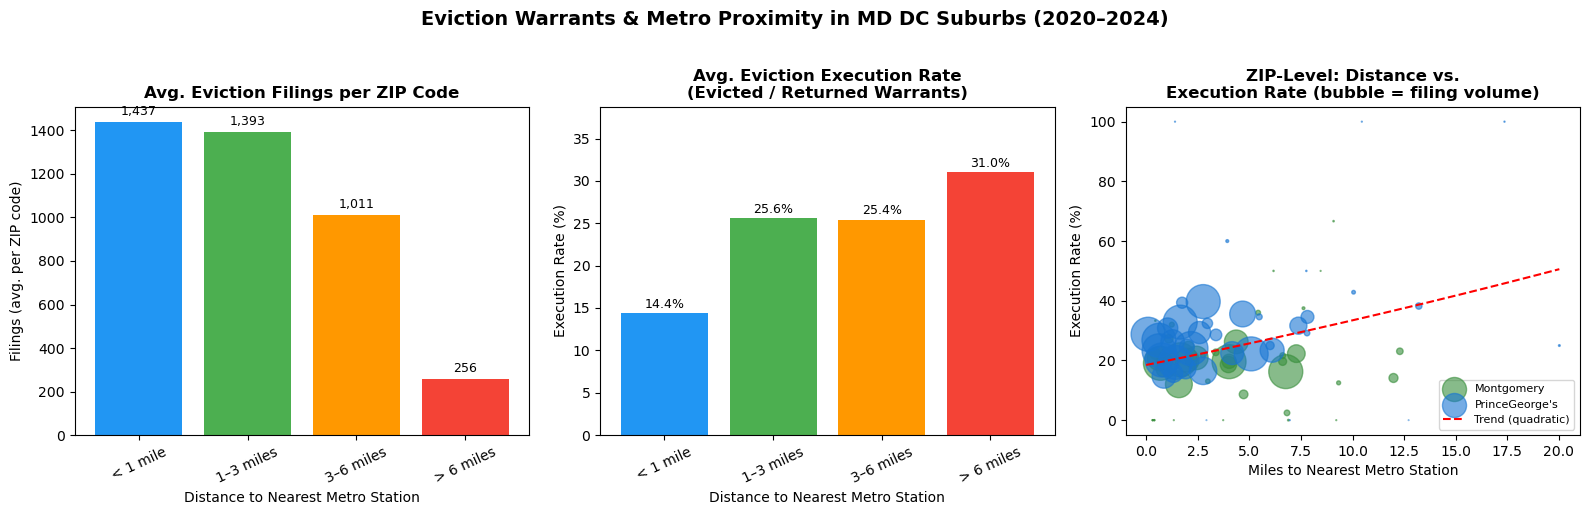

Figure saved as metro_evictions_panels.png


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    "Eviction Warrants & Metro Proximity in MD DC Suburbs (2020–2024)",
    fontsize=14, fontweight='bold', y=1.02
)

palette = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']

# Panel A: Total filings per ZIP code by zone
ax = axes[0]
bars = ax.bar(
    zone_summary['ProximityZone'],
    zone_summary['FilingsPerZIP'],
    color=palette
)
ax.set_title('Avg. Eviction Filings per ZIP Code', fontweight='bold')
ax.set_xlabel('Distance to Nearest Metro Station')
ax.set_ylabel('Filings (avg. per ZIP code)')
ax.tick_params(axis='x', rotation=25)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9)

# Panel B: Eviction execution rate by zone
ax = axes[1]
bars = ax.bar(
    zone_summary['ProximityZone'],
    zone_summary['AvgExecRate'],
    color=palette
)
ax.set_title('Avg. Eviction Execution Rate\n(Evicted / Returned Warrants)', fontweight='bold')
ax.set_xlabel('Distance to Nearest Metro Station')
ax.set_ylabel('Execution Rate (%)')
ax.tick_params(axis='x', rotation=25)
ax.set_ylim(0, max(zone_summary['AvgExecRate']) * 1.25)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

# Panel C: Scatter — distance vs. execution rate (ZIP level), coloured by county
ax = axes[2]
county_colors = {"PrinceGeorge's": '#1976D2', 'Montgomery': '#388E3C'}
for county, grp in zip_nearest.dropna(subset=['ExecutionRate']).groupby('County'):
    ax.scatter(
        grp['DistMiles'],
        grp['ExecutionRate'] * 100,
        label=county,
        alpha=0.6,
        s=grp['TotalFilings'].clip(upper=3000) / 5,  # bubble size ~ filings
        color=county_colors.get(county, 'grey')
    )
# Add trend line
valid = zip_nearest.dropna(subset=['ExecutionRate', 'DistMiles'])
z = np.polyfit(valid['DistMiles'], valid['ExecutionRate'] * 100, 2)
p = np.poly1d(z)
x_line = np.linspace(0, valid['DistMiles'].max(), 200)
ax.plot(x_line, p(x_line), 'r--', linewidth=1.5, label='Trend (quadratic)')
ax.set_title('ZIP-Level: Distance vs.\nExecution Rate (bubble = filing volume)', fontweight='bold')
ax.set_xlabel('Miles to Nearest Metro Station')
ax.set_ylabel('Execution Rate (%)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('metro_evictions_panels.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as metro_evictions_panels.png")

---
## 8. Map: Eviction Filing Intensity and Metro Stations

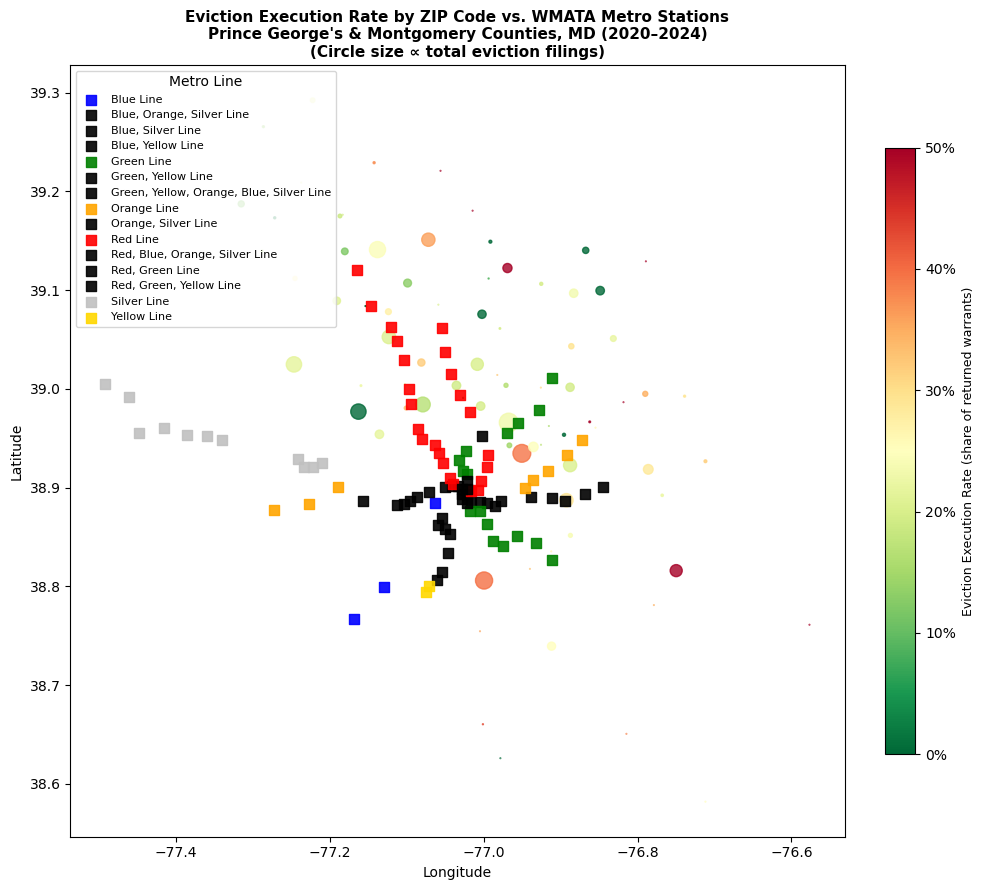

Map saved as metro_evictions_map.png


In [21]:
fig, ax = plt.subplots(1, 1, figsize=(11, 9))

# Plot ZIP centroids sized by filings, coloured by execution rate
sc = zip_nearest.to_crs('EPSG:4326').plot(
    ax=ax,
    column='ExecutionRate',
    cmap='RdYlGn_r',
    markersize=(zip_nearest['TotalFilings'].clip(lower=10) / 40),
    legend=False,
    alpha=0.8,
    vmin=0, vmax=0.5
)

# Overlay all Metro stations
line_colors = {
    'red': 'red', 'blue': 'blue', 'green': 'green',
    'orange': 'orange', 'silver': 'silver', 'yellow': 'gold'
}
for line, grp in metro.to_crs('EPSG:4326').groupby('LINE'):
    grp.plot(ax=ax, color=line_colors.get(line, 'black'),
             markersize=60, marker='s', alpha=0.9, label=f'{line.title()} Line')

# Colorbar
sm = plt.cm.ScalarMappable(cmap='RdYlGn_r', norm=plt.Normalize(vmin=0, vmax=0.5))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label('Eviction Execution Rate (share of returned warrants)', fontsize=9)
cbar.ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

ax.set_title(
    'Eviction Execution Rate by ZIP Code vs. WMATA Metro Stations\n'
    'Prince George\'s & Montgomery Counties, MD (2020–2024)\n'
    '(Circle size ∝ total eviction filings)',
    fontsize=11, fontweight='bold'
)
ax.legend(loc='upper left', fontsize=8, title='Metro Line')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.tight_layout()
plt.savefig('metro_evictions_map.png', dpi=150, bbox_inches='tight')
plt.show()
print("Map saved as metro_evictions_map.png")

---
## 9. Statistical Summary: County × Proximity Zone Breakdown

In [24]:
county_zone = (
    zip_nearest
    .groupby(['County', 'ProximityZone'], observed=True)
    .agg(
        NumZIPs       = ('ZipCode',       'count'),
        TotalFilings  = ('TotalFilings',  'sum'),
        TotalExecuted = ('Executed',      'sum'),
        AvgExecRate   = ('ExecutionRate', 'mean'),
    )
    .reset_index()
)
county_zone['AvgExecRate_pct'] = (county_zone['AvgExecRate'] * 100).round(1)
county_zone['FilingsPerZIP']   = (county_zone['TotalFilings'] / county_zone['NumZIPs']).round(0)

print(county_zone[['County','ProximityZone','NumZIPs','FilingsPerZIP','AvgExecRate_pct']].to_string(index=False))

        County ProximityZone  NumZIPs  FilingsPerZIP  AvgExecRate_pct
    Montgomery      < 1 mile       12          546.0             11.0
    Montgomery     1–3 miles       11          777.0             19.2
    Montgomery     3–6 miles        8          838.0             18.9
    Montgomery     > 6 miles       14          326.0             24.0
PrinceGeorge's      < 1 mile        7         2965.0             22.7
PrinceGeorge's     1–3 miles       18         1770.0             29.9
PrinceGeorge's     3–6 miles        7         1208.0             33.9
PrinceGeorge's     > 6 miles       16          195.0             38.5


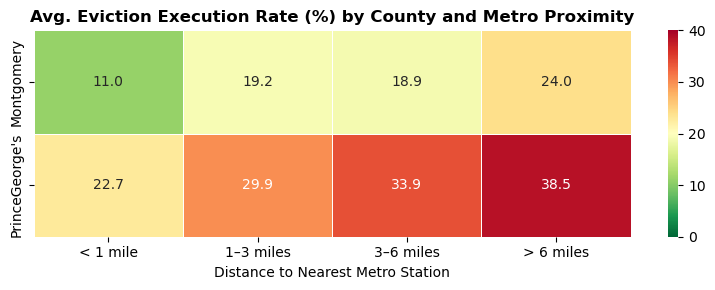

In [25]:
# Heatmap: execution rate by county × proximity zone
pivot = county_zone.pivot(
    index='County', columns='ProximityZone', values='AvgExecRate_pct'
)
pivot = pivot[LABELS]  # reorder columns

fig, ax = plt.subplots(figsize=(8, 3))
sns.heatmap(
    pivot,
    annot=True, fmt='.1f',
    cmap='RdYlGn_r',
    vmin=0, vmax=40,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Avg. Eviction Execution Rate (%) by County and Metro Proximity', fontweight='bold')
ax.set_xlabel('Distance to Nearest Metro Station')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('execution_rate_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Year-over-Year Trend by Proximity Zone

Has the relationship between transit access and eviction outcomes changed since COVID-era protections ended?

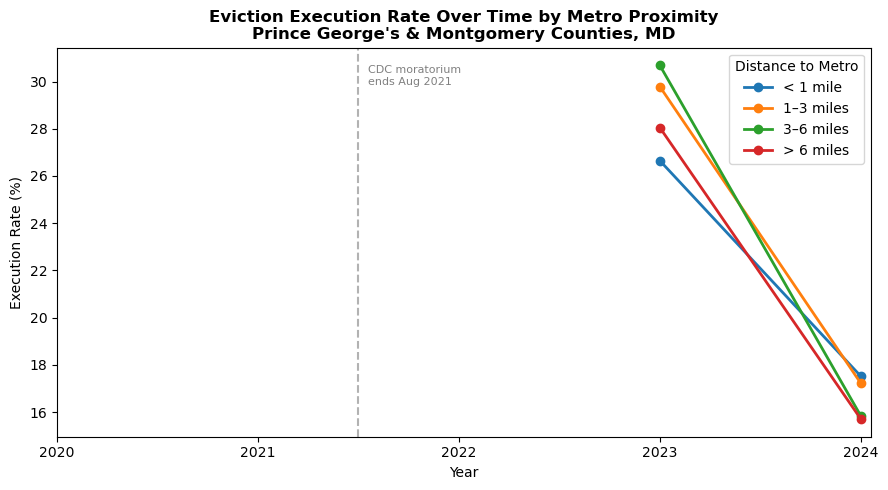

In [26]:
# Attach proximity zone back to record-level data
zip_to_zone = zip_nearest[['ZipCode', 'ProximityZone']].copy()

df_merged = df.merge(zip_to_zone, on='ZipCode', how='inner')

# Annual execution rate by proximity zone
annual = (
    df_merged[df_merged['Outcome'].isin(['Executed', 'Cancelled', 'Expired'])]
    .groupby(['Year', 'ProximityZone'], observed=True)
    .apply(lambda g: (g['Outcome'] == 'Executed').sum() / len(g))
    .reset_index(name='ExecRate')
)
annual['Year'] = annual['Year'].astype(int)

fig, ax = plt.subplots(figsize=(9, 5))
for zone, grp in annual.groupby('ProximityZone', observed=True):
    ax.plot(grp['Year'], grp['ExecRate'] * 100, marker='o', label=zone, linewidth=2)

ax.set_title(
    'Eviction Execution Rate Over Time by Metro Proximity\n'
    'Prince George\'s & Montgomery Counties, MD',
    fontweight='bold'
)
ax.set_xlabel('Year')
ax.set_ylabel('Execution Rate (%)')
ax.set_xticks([2020, 2021, 2022, 2023, 2024])
ax.legend(title='Distance to Metro')
ax.axvline(2021.5, color='grey', linestyle='--', alpha=0.6, label='CDC moratorium ends')
ax.text(2021.55, ax.get_ylim()[1]*0.95, 'CDC moratorium\nends Aug 2021', fontsize=8, color='grey')
plt.tight_layout()
plt.savefig('annual_trend_by_zone.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 11. Key Findings Summary

In [27]:
print("=" * 65)
print("KEY FINDINGS")
print("=" * 65)

# Finding 1: filing concentration near transit
near  = zone_summary[zone_summary['ProximityZone'] == '< 1 mile']['FilingsPerZIP'].values[0]
far   = zone_summary[zone_summary['ProximityZone'] == '> 6 miles']['FilingsPerZIP'].values[0]
print(f"\n1. Eviction filing concentration:")
print(f"   ZIP codes within 1 mile of a Metro station average {near:,.0f} filings,")
print(f"   vs. {far:,.0f} for ZIP codes more than 6 miles away.")

# Finding 2: execution rate pattern
exec_rates = zone_summary.set_index('ProximityZone')['AvgExecRate']
print(f"\n2. Eviction execution rate by proximity zone:")
for zone, rate in exec_rates.items():
    print(f"   {zone:12s}: {rate:.1f}%")

# Finding 3: highest-risk county/zone combination
worst = county_zone.sort_values('AvgExecRate_pct', ascending=False).iloc[0]
print(f"\n3. Highest execution rate: {worst['County']} County in the '{worst['ProximityZone']}' zone")
print(f"   ({worst['AvgExecRate_pct']:.1f}% of returned warrants result in eviction)")

print("\n" + "=" * 65)

KEY FINDINGS

1. Eviction filing concentration:
   ZIP codes within 1 mile of a Metro station average 1,437 filings,
   vs. 256 for ZIP codes more than 6 miles away.

2. Eviction execution rate by proximity zone:
   < 1 mile    : 14.4%
   1–3 miles   : 25.6%
   3–6 miles   : 25.4%
   > 6 miles   : 31.0%

3. Highest execution rate: PrinceGeorge's County in the '> 6 miles' zone
   (38.5% of returned warrants result in eviction)

